# 09 — LUT-density convergence check

Addresses review point **M4** (optional/polish, an external methods review not included in this repository): the 8000-sample reference LUT used throughout notebooks 03-08 is ~3.6 samples per dimension in the 7-D parameter space — coarse for nearest-neighbour retrieval. Part of the reported RMSE could be LUT granularity rather than a genuine spectral-information limit. This notebook re-runs the canonical hyperspectral-baseline self-consistency test (same seeds as notebook 03: LUT seed 42, truth seed 1234, noise seed 0, unweighted-SSR cost, full valid-band subset) at LUT sizes 8k / 32k / 128k and checks whether the metrics have stabilised.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, str(Path.cwd().parent))
from src import tanager_io, prospect_inversion as pi, channel_selector as cs, metrics

In [2]:
SCENE_SR_PATH = Path("../data/tanager_scene_01/scene_basic_sr.h5")
scene = tanager_io.load_surface_reflectance(SCENE_SR_PATH)
wavelengths = scene.wavelengths
invalid_pixels = scene.cloud_mask | scene.cirrus_mask | scene.nodata_mask
mean_sun_zenith = float(np.nanmean(scene.sun_zenith[~invalid_pixels]))
valid_bands = cs.valid_band_mask(wavelengths)

truth_lut = pi.generate_lut(n_samples=300, wavelengths=wavelengths, seed=1234, tts=mean_sun_zenith)
rng = np.random.default_rng(0)
noisy_truth_spectra = truth_lut["spectra"] + rng.normal(0, 0.005, size=truth_lut["spectra"].shape)
true_params = truth_lut["parameters"]

rows = []
for n_lut in [8000, 32000, 128000]:
    reference_lut = pi.generate_lut(n_samples=n_lut, wavelengths=wavelengths, seed=42, tts=mean_sun_zenith)
    retrieved = pi.invert_lut_batch(noisy_truth_spectra, reference_lut, wavelength_mask=valid_bands)
    for j, name in enumerate(reference_lut["parameter_names"]):
        t, r = true_params[:, j], retrieved[:, j]
        lo, hi = pi.PARAMETER_RANGES[name]
        rows.append({
            "n_lut": n_lut,
            "parameter": name,
            "rmse": metrics.rmse(t, r),
            "r_squared": metrics.r_squared(t, r),
            "relative_rmse_pct": 100 * metrics.rmse(t, r) / (hi - lo),
        })
    print(f"n_lut={n_lut} done")

convergence = pd.DataFrame(rows)
convergence.to_csv("../results/tables/10_lut_convergence_stats.csv", index=False)
convergence.pivot(index="parameter", columns="n_lut", values="r_squared")

n_lut=8000 done


n_lut=32000 done


n_lut=128000 done


n_lut,8000,32000,128000
parameter,,,
Ant,0.043571,0.238022,0.495178
Cab,0.855953,0.918334,0.946909
Car,-0.464164,-0.235030,0.038611
Cm,0.682503,0.765536,0.822299
Cw,0.869690,0.900515,0.938796
LAI,0.489582,0.552618,0.628517
N,0.167593,0.307661,0.542900


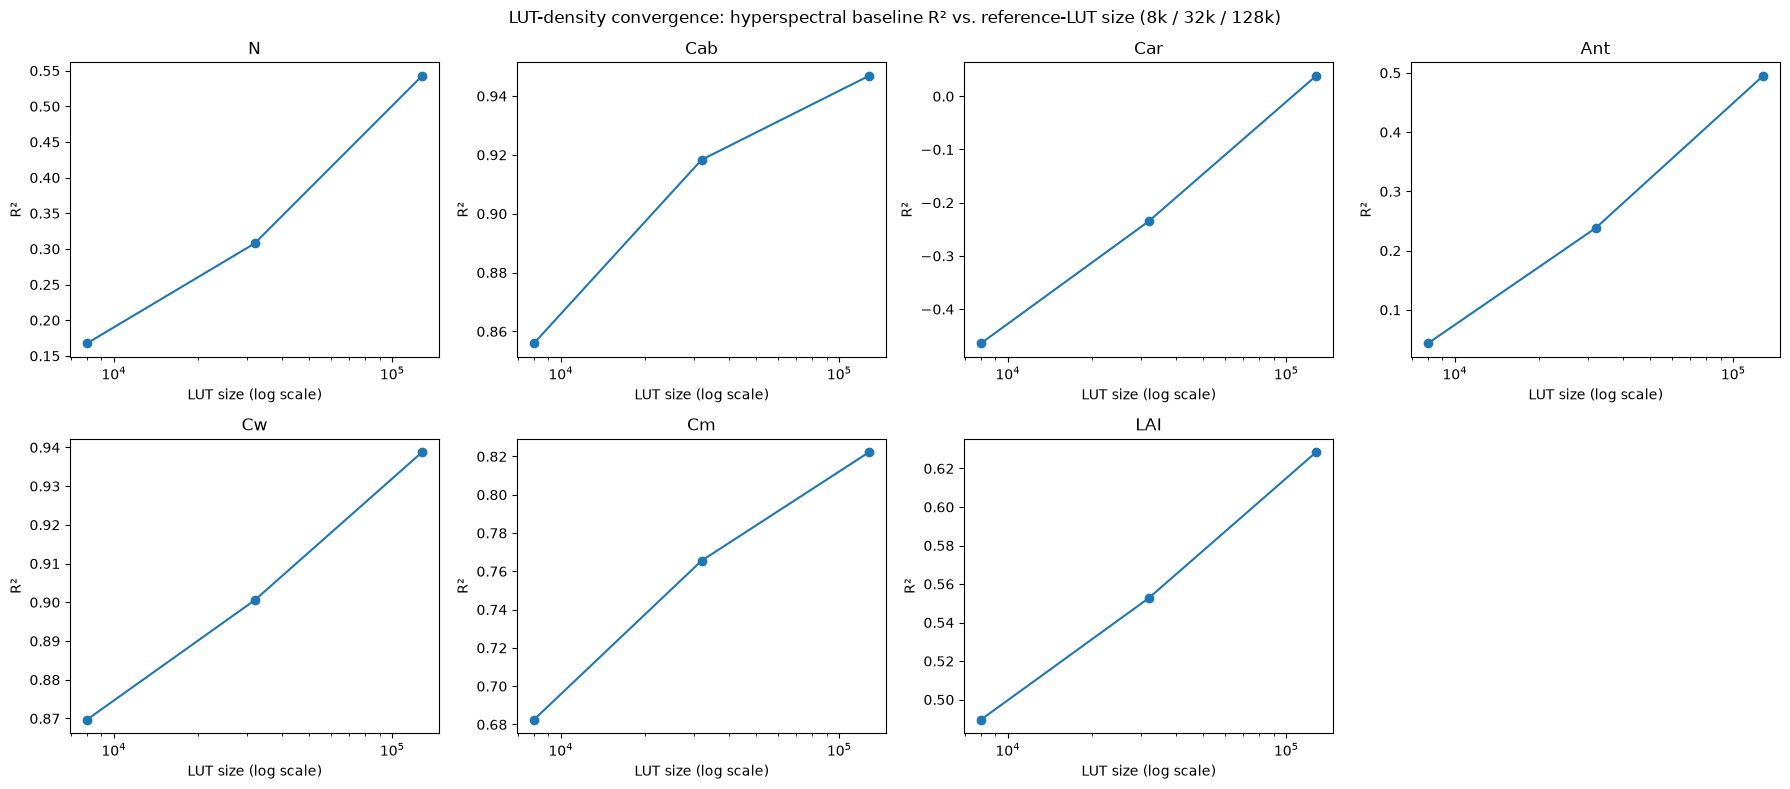

In [3]:
param_names = convergence["parameter"].unique()
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, param in zip(axes.flat, param_names):
    sub = convergence[convergence["parameter"] == param].sort_values("n_lut")
    ax.plot(sub["n_lut"], sub["r_squared"], marker="o")
    ax.set_xscale("log")
    ax.set_title(param)
    ax.set_xlabel("LUT size (log scale)")
    ax.set_ylabel("R\u00b2")
axes.flat[-1].axis("off")
plt.suptitle("LUT-density convergence: hyperspectral baseline R\u00b2 vs. reference-LUT size (8k / 32k / 128k)")
plt.tight_layout()
plt.savefig("../results/figures/10_lut_convergence.png", dpi=150)
plt.show()

## Reading the convergence result

If R\u00b2 for each parameter is essentially flat from 8k to 128k, the 8000-sample LUT used throughout notebooks 03-08 is not the accuracy floor for this comparison — the reported retrieval quality differences between subsets reflect spectral information content, not LUT coarseness. See the table above for the per-parameter numbers feeding this conclusion in `RESPONSE_TO_REVIEW.md`.

## Does the "±100 nm ≥ full hyperspectral" gap survive LUT densification?

A methods review raised the priority open question this section did not originally test: the subset comparison in notebooks 03-06 (5-band vs. targeted SWIR windows vs. full 366-band hyperspectral) was run *only* at the 8,000-sample LUT. Since full hyperspectral has 366 bands to exploit against the LUT grid versus 85 for the ±100 nm window, it is plausible the *full-hyperspectral* retrieval benefits more from a denser LUT than the narrower SWIR subset does — in which case the "targeted SWIR beats full hyperspectral" gap (currently +0.029 for Cw at 8k) could narrow or reverse as the LUT densifies, rather than being a stable property of the spectral information content. This was previously untested. We re-use the same 8k/32k/128k reference LUTs above (one generation per size, canonical seeds), but now invert the canonical truth set against each spectral subset (not just the full valid-band set) at each LUT size.

In [4]:
swir_masks = cs.swir_incremental_subsets(wavelengths, cs.MULTISPECTRAL_BANDS_NM, swir_window_nm=50.0, n_steps=4)
subset_labels = ["5-band multispectral (no SWIR)"] + [f"+ SWIR window ±{50*step} nm" for step in range(1, 5)]
subset_masks = list(swir_masks)
subset_labels.append("Full hyperspectral (valid bands)")
subset_masks.append(valid_bands)

rows_by_subset = []
for n_lut in [8000, 32000, 128000]:
    reference_lut = pi.generate_lut(n_samples=n_lut, wavelengths=wavelengths, seed=42, tts=mean_sun_zenith)
    for label, mask in zip(subset_labels, subset_masks):
        retrieved = pi.invert_lut_batch(noisy_truth_spectra, reference_lut, wavelength_mask=mask)
        for j, name in enumerate(reference_lut["parameter_names"]):
            t, r = true_params[:, j], retrieved[:, j]
            lo, hi = pi.PARAMETER_RANGES[name]
            rows_by_subset.append({
                "n_lut": n_lut,
                "subset": label,
                "n_bands": int(mask.sum()),
                "parameter": name,
                "rmse": metrics.rmse(t, r),
                "r_squared": metrics.r_squared(t, r),
                "relative_rmse_pct": 100 * metrics.rmse(t, r) / (hi - lo),
            })
    print(f"n_lut={n_lut}: all subsets done")

convergence_by_subset = pd.DataFrame(rows_by_subset)
convergence_by_subset.to_csv("../results/tables/10_lut_convergence_by_subset.csv", index=False)

cw_by_subset = convergence_by_subset[convergence_by_subset["parameter"] == "Cw"]
cw_pivot = cw_by_subset.pivot(index="subset", columns="n_lut", values="r_squared").loc[subset_labels]
cw_pivot

n_lut=8000: all subsets done


n_lut=32000: all subsets done


n_lut=128000: all subsets done


n_lut,8000,32000,128000
subset,,,
5-band multispectral (no SWIR),-0.975823,-0.872048,-1.040018
+ SWIR window ±50 nm,0.834474,0.838216,0.873121
+ SWIR window ±100 nm,0.921640,0.929053,0.941885
+ SWIR window ±150 nm,0.911800,0.942797,0.955492
+ SWIR window ±200 nm,0.921037,0.946762,0.953393
Full hyperspectral (valid bands),0.869690,0.900515,0.938796


Cw R^2 gap, +-100nm minus full hyperspectral, by LUT size:
n_lut
8000      0.051949
32000     0.028538
128000    0.003089
dtype: float64

Cw R^2 gap, +-150nm minus full hyperspectral, by LUT size:
n_lut
8000      0.042110
32000     0.042282
128000    0.016696
dtype: float64


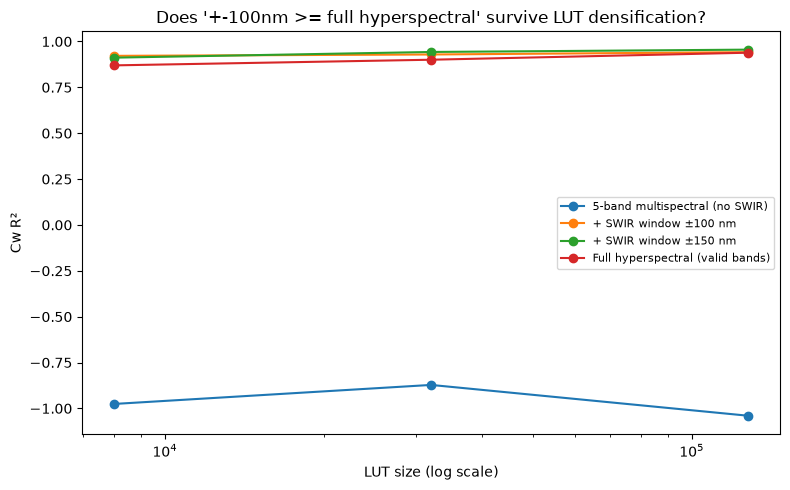

In [5]:
gap_100_vs_full = cw_pivot.loc["+ SWIR window ±100 nm"] - cw_pivot.loc["Full hyperspectral (valid bands)"]
gap_150_vs_full = cw_pivot.loc["+ SWIR window ±150 nm"] - cw_pivot.loc["Full hyperspectral (valid bands)"]
print("Cw R^2 gap, +-100nm minus full hyperspectral, by LUT size:")
print(gap_100_vs_full)
print()
print("Cw R^2 gap, +-150nm minus full hyperspectral, by LUT size:")
print(gap_150_vs_full)

fig, ax = plt.subplots(figsize=(8, 5))
for label in ["5-band multispectral (no SWIR)", "+ SWIR window ±100 nm", "+ SWIR window ±150 nm", "Full hyperspectral (valid bands)"]:
    sub = cw_by_subset[cw_by_subset["subset"] == label].sort_values("n_lut")
    ax.plot(sub["n_lut"], sub["r_squared"], marker="o", label=label)
ax.set_xscale("log")
ax.set_xlabel("LUT size (log scale)")
ax.set_ylabel("Cw R²")
ax.legend(fontsize=8)
ax.set_title("Does '+-100nm >= full hyperspectral' survive LUT densification?")
plt.tight_layout()
plt.savefig("../results/figures/10_lut_convergence_by_subset_Cw.png", dpi=150)
plt.show()

## Does the ±100 nm-vs-full margin survive at 32k with more than one realisation?

A subsequent methods review (cycle 4, point D1) noted an asymmetry: the "±100 nm ≥ full hyperspectral" claim above was *established* on 30 independent seed triples (`06_multiseed_and_cost_ablation.ipynb`), but the density check that *revises* it (the cell above) uses a single LUT/truth/noise draw per (subset, LUT size) — no error bars. Since §3.6 argues that behaviour changes with LUT density, the realisation SD measured at 8k cannot simply be assumed to hold at 32k. This cell re-runs the canonical subset comparison at **n_reference_lut = 32000** over **5 independent seed triples** (a new master seed, distinct from both the 8k canonical single draw above and the 30-seed 8k robustness study), using `experiments.run_subset_experiment` (already used for the 30-seed 8k study) so the 32k margin gets a mean ± SD instead of resting on one point. 128k×5 is not attempted here (cost); 32k×5 is the cheap, decisive middle point the review asked for.

In [6]:
from src import experiments

D1_N_SEEDS = 5
d1_master_rng = np.random.default_rng(2028)
d1_seed_triples = [
    tuple(int(x) for x in d1_master_rng.integers(0, 1_000_000, size=3)) for _ in range(D1_N_SEEDS)
]

d1_subset_labels = ["5-band multispectral (no SWIR)", "+ SWIR window ±100 nm", "+ SWIR window ±150 nm", "Full hyperspectral (valid bands)"]
d1_subset_masks = [subset_masks[subset_labels.index(lbl)] for lbl in d1_subset_labels]

d1_df = experiments.run_subset_experiment(
    seed_triples=d1_seed_triples,
    subset_masks=d1_subset_masks,
    subset_labels=d1_subset_labels,
    wavelengths=wavelengths,
    tts=mean_sun_zenith,
    costs=("sse",),
    n_reference_lut=32000,
    n_truth=300,
    noise_sigma=0.005,
)
d1_df.to_csv("../results/tables/11_lut_convergence_32k_multiseed.csv", index=False)
print(d1_df.shape)
d1_df.head()

(140, 11)


,seed_idx,lut_seed,truth_seed,noise_seed,cost,subset,n_bands,parameter,rmse,r_squared,relative_rmse_pct
0,0,565417,386752,356943,sse,5-band multispectral (no SWIR),5,N,0.444945,-0.055937,29.663031
1,0,565417,386752,356943,sse,5-band multispectral (no SWIR),5,Cab,7.324905,0.899374,9.156131
2,0,565417,386752,356943,sse,5-band multispectral (no SWIR),5,Car,7.779481,-0.815597,38.897407
3,0,565417,386752,356943,sse,5-band multispectral (no SWIR),5,Ant,1.923286,0.556186,19.232862
4,0,565417,386752,356943,sse,5-band multispectral (no SWIR),5,Cw,0.019000,-0.880319,39.583953


In [7]:
d1_cw = d1_df[d1_df["parameter"] == "Cw"]
d1_pivot = d1_cw.pivot(index="seed_idx", columns="subset", values="r_squared")[d1_subset_labels]

d1_margin_100 = d1_pivot["+ SWIR window ±100 nm"] - d1_pivot["Full hyperspectral (valid bands)"]
d1_margin_150 = d1_pivot["+ SWIR window ±150 nm"] - d1_pivot["Full hyperspectral (valid bands)"]

print("Cw R^2, per seed, at n_lut=32000:")
print(d1_pivot)
print()
print(f"±100 nm margin over full at 32k, n={D1_N_SEEDS} seeds: mean={d1_margin_100.mean():.4f}, sd={d1_margin_100.std(ddof=1):.4f}")
print(f"±150 nm margin over full at 32k, n={D1_N_SEEDS} seeds: mean={d1_margin_150.mean():.4f}, sd={d1_margin_150.std(ddof=1):.4f}")
print()
print("For comparison, the single-draw 8k/32k/128k +-100nm-vs-full margins (cell above) were: +0.0519 / +0.0285 / +0.0031")

Cw R^2, per seed, at n_lut=32000:
subset    5-band multispectral (no SWIR)  + SWIR window ±100 nm  \
seed_idx                                                          
0                              -0.880319               0.918484   
1                              -0.905712               0.927050   
2                              -1.137381               0.939508   
3                              -0.931986               0.922503   
4                              -1.144157               0.928084   

subset    + SWIR window ±150 nm  Full hyperspectral (valid bands)  
seed_idx                                                           
0                      0.919073                          0.901600  
1                      0.934265                          0.916398  
2                      0.928410                          0.902778  
3                      0.930121                          0.911741  
4                      0.924370                          0.906819  

±100 nm margin over